# Universidad Libre - Seccional Cali<br>Facultad de Ingeniería - Diplomado en Ciencia de Datos<br>(ↄ) Daniel Andres Barona Sandoval, 2026

# 04_modelo
Plantilla para el desarrollo del proyecto del diplomado de Ciencia de Datos, aplicando buenas prácticas.

---

Este cuaderno representa la culminación del proceso, donde aplicamos técnicas de machine learning para crear modelos predictivos o descriptivos basados en los datos preparados.

**Propósito:** Desarrollar, entrenar y validar modelos de machine learning que respondan a los objetivos del proyecto.

**Tareas habituales:**
- Selección de características (feature selection)
- Ingeniería de características (feature engineering)
- División de datos en conjuntos de entrenamiento y prueba
- Selección y entrenamiento de modelos
- Optimización de hiperparámetros
- Validación cruzada
- Evaluación de métricas de rendimiento
- Documentación del proceso de modelado
- Guardado y versionado de modelos
- Análisis de importancia de características

In [1]:
!rm -rf /content/proyecto_ciencia_datos

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
import os
warnings.filterwarnings("ignore")
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import joblib
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display

In [3]:
!pip install pmdarima

In [4]:
try:
    import pmdarima as pm
    from pmdarima.arima.utils import ndiffs, nsdiffs
    HAS_PMDARIMA = True
except ImportError:
    HAS_PMDARIMA = False
    print('pmdarima no instalado: se usara grid search propio')

In [5]:
!git clone https://github.com/daniel-barona/proyecto_ciencia_datos

Cloning into 'proyecto_ciencia_datos'...
remote: Enumerating objects: 474, done.
remote: Counting objects: 100% (154/154), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 474 (delta 129), reused 82 (delta 82), pack-reused 320 (from 1)
Receiving objects: 100% (474/474), 610.37 MiB | 21.75 MiB/s, done.
Resolving deltas: 100% (273/273), done.
Updating files: 100% (56/56), done.


In [6]:
folder_path = Path("/content/proyecto_ciencia_datos/data/trusted")
files = list(folder_path.glob("*.xlsx"))
print(f"Archivos encontrados: {len(files)}")
for file in files:
    print(file.name)

Archivos encontrados: 1
SIPSA_2013_2026_trusted.xlsx


# DISEÑO DEL ALGORITMO

**La idea del algoritmo es la siguiente:**

1. El usuario debe seleccinar el departamento que desee estudiar, (puede escoger los departamentos disponibles, bogota esta incluido en la lista por el datset y Colombia tambien va a estar disponible si el usuario desea hacer un estudio a nivel nacional)
2. Despues de escoger el departamento (excluyendo bogota y colombia) el usuario podra escoger entre de las ciudades de ese departamento que pertenecen y que tienen activo centros de venta mayorista para poductos alimentarios.
3. Una vez escogido se le debe mostrar los productos disponibles en la ciudad.
4. el usuario escoge el producto a investigar.
5. Alli se empieza a realizar la estadistica, la idea es hacer selecion de todas las soliitudes realizadas por el usuario y realizar un problema de serie de tiempo
- Opcion A: usar los promedios mensuales por año (solicitud del cliente)
- Opcion B: recoletar todos los datos obtenidos de la solicitud de usuario por año
6. Debe realizar el analisis, presentar las graficas, presentar promedio de mes mensual actual (hasta junio) y dar la probabilidad del precio del producto en la cuidad seleccionada.


In [7]:
trusted_dir = "/content/proyecto_ciencia_datos/data/trusted"
df = pd.read_excel(f"{trusted_dir}/SIPSA_2013_2026_trusted.xlsx")
df

,fecha,grupo,producto,mercado,departamento,codigo_departamento,municipio,codigo_municipio,precio_promedio_kg,circulacion
0,2013-01-01,carnes,alas de pollo con costillar,"barranquilla, barranquillita",atlantico,8,barranquilla,8001,3073.0,si
1,2013-01-01,carnes,alas de pollo con costillar,"bogota, d.c., frigorifico guadalupe","bogota, d.c.",11,"bogota, d.c.",11001,2560.0,si
2,2013-01-01,carnes,alas de pollo con costillar,"cartagena, bazurto",bolivar,13,cartagena de indias,13001,3429.0,si
3,2013-01-01,carnes,alas de pollo con costillar,"ibague, plaza la 21",tolima,73,ibague,73001,4307.0,si
4,2013-01-01,carnes,alas de pollo con costillar,"medellin, plaza minorista ""jose maria villa""",antioquia,5,medellin,5001,3717.0,si
...,...,...,...,...,...,...,...,...,...,...
749048,2026-06-01,frutas,manzana royal gala importada,"neiva, surabastos",huila,41,neiva,41001,8706.0,si
749049,2026-06-01,frutas,manzana royal gala importada,"monteria, mercado del sur",cordoba,23,monteria,23001,8573.0,si
749050,2026-06-01,frutas,manzana royal gala importada,"medellin, central mayorista de antioquia",antioquia,5,medellin,5001,7517.0,si
749051,2026-06-01,frutas,naranja valencia,"valledupar, mercabastos",cesar,20,valledupar,20001,2494.0,si


## Entrenar el Modelo

In [8]:
departamentos_2026 = sorted(
    df.loc[df["fecha"].dt.year == 2026, "departamento"]
      .dropna()
      .unique()
)
departamentos_2026

['antioquia',
 'arauca',
 'atlantico',
 'bogota, d.c.',
 'bolivar',
 'boyaca',
 'caldas',
 'caqueta',
 'casanare',
 'cauca',
 'cesar',
 'cordoba',
 'cundinamarca',
 'huila',
 'magdalena',
 'meta',
 'narino',
 'norte de santander',
 'quindio',
 'risaralda',
 'santander',
 'sucre',
 'tolima',
 'valle del cauca']

In [9]:
departamentos = ['colombia'] + departamentos_2026

In [10]:
dropdown_departamento = widgets.Dropdown(
    options=departamentos,
    description='Departamento:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)
display(dropdown_departamento)

Dropdown(description='Departamento:', layout=Layout(width='400px'), options=('colombia', 'antioquia', 'arauca'…

In [11]:
departamento = dropdown_departamento.value
print("Departamento seleccionado:", departamento)

Departamento seleccionado: santander


In [12]:
if departamento.lower() not in ['colombia', 'bogota, d.c.']:
    municipios = sorted(
        df[
            (df["departamento"] == departamento) &
            (df["fecha"].dt.year == 2026)
        ]["municipio"]
        .dropna()
        .unique()
        .tolist()
    )

    dropdown_municipio = widgets.Dropdown(
        options=municipios,
        description='Municipio:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )

    display(dropdown_municipio)

else:
    print("No es necesario seleccionar un municipio.")

Dropdown(description='Municipio:', layout=Layout(width='400px'), options=('bucaramanga', 'charala', 'guepsa', …

In [13]:
if departamento.lower() not in ['colombia', 'bogota, d.c.']:
    municipio = dropdown_municipio.value
    print("Municipio seleccionado:", municipio)

Municipio seleccionado: bucaramanga


In [14]:
if departamento.lower() == 'colombia':
    # Modo nacional: no se elige un mercado especifico, se promediara
    # el producto seleccionado en TODOS los mercados del pais.
    print("Modo nacional seleccionado: el producto se promediara entre todos los mercados del pais.")

elif departamento.lower() == 'bogota, d.c.':

    mercados = sorted(
        df[
            (df["departamento"] == departamento) &
            (df["fecha"].dt.year == 2026)
        ]["mercado"]
        .dropna()
        .unique()
        .tolist()
    )

    dropdown_mercado = widgets.Dropdown(
        options=mercados,
        description='Mercado:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )
    display(dropdown_mercado)

else:

    municipio = dropdown_municipio.value

    mercados = sorted(
        df[
            (df["municipio"] == municipio) &
            (df["fecha"].dt.year == 2026)
        ]["mercado"]
        .dropna()
        .unique()
        .tolist()
    )

    dropdown_mercado = widgets.Dropdown(
        options=mercados,
        description='Mercado:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )
    display(dropdown_mercado)

Dropdown(description='Mercado:', layout=Layout(width='400px'), options=('bucaramanga, arrocera el dorado', 'bu…

In [15]:
if departamento.lower() == 'colombia':
    mercado = None
    print("Mercado: N/A (se calculará el promedio nacional)")
else:
    mercado = dropdown_mercado.value
    print("Mercado seleccionado:", mercado)

Mercado seleccionado: bucaramanga, mercados del centro


In [16]:
if mercado is None:
    # Nacional: productos disponibles en cualquier mercado del pais
    productos = sorted(
        df[df["fecha"].dt.year == 2026]["producto"]
        .dropna()
        .unique()
        .tolist()
    )
else:
    productos = sorted(
        df[
            (df["mercado"] == mercado) &
            (df["fecha"].dt.year == 2026)
        ]["producto"]
        .dropna()
        .unique()
        .tolist()
    )

dropdown_producto = widgets.Dropdown(
    options=productos,
    description='Producto:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)
display(dropdown_producto)

Dropdown(description='Producto:', layout=Layout(width='400px'), options=('arroz de primera', 'arroz sopa crist…

In [17]:
producto = dropdown_producto.value
print("Producto seleccionado:", producto)

Producto seleccionado: queso campesino


## Inicio del Modelo - Hacer Pruebas

##Variables predefinidas

In [18]:
M = 12                  # Periodicidad estacional: 12 meses = ciclo anual
TEST_SIZE = 12          # Ultimos 12 meses reservados exclusivamente para TEST
H_FUTURO = 12           # Pronostico de los proximos 12 meses

# Fase 1: creacion de la serie

In [19]:
# Si mercado es None (modo nacional / departamento = 'colombia'), se  promedian los precios del producto entre TODOS los mercados del pais.
def preparar_serie(df, producto, mercado=None):
    base = df[df['producto'] == producto]
    if mercado is not None:
        base = base[base['mercado'] == mercado]

    serie = base[['fecha', 'precio_promedio_kg']].copy()
    serie = serie.sort_values('fecha')
    serie.set_index('fecha', inplace=True)
    serie.rename(columns={'precio_promedio_kg': 'precio'}, inplace=True)
    # Promedio de todos los registros de la misma fecha
    # (varios mercados/municipios reportando el mismo mes)
    serie = serie.groupby(serie.index).mean()
    # Frecuencia mensual + relleno de huecos
    serie = serie.asfreq('MS').interpolate('linear').ffill().bfill()
    return serie['precio']

y = preparar_serie(df, producto, mercado)
mercado_label = 'Colombia (promedio nacional)' if mercado is None else mercado
print(f'Serie construida ({mercado_label}): {len(y)} observaciones, '
      f'de {y.index[0].strftime("%Y-%m")} a {y.index[-1].strftime("%Y-%m")}')

display(y.round(2))

Serie construida (bucaramanga, mercados del centro): 162 observaciones, de 2013-01 a 2026-06


,precio
fecha,
2013-01-01,9000.0
2013-02-01,9000.0
2013-03-01,9000.0
2013-04-01,9000.0
2013-05-01,8867.0
...,...
2026-02-01,19917.0
2026-03-01,20000.0
2026-04-01,20200.0


## Fase 2 — Verificación de la serie y división Train / Test

Antes de modelar, comprueba que la serie tenga suficientes observaciones. Reglas prácticas para SARIMA con estacionalidad mensual (m=12):

- **< 24 meses**: insuficiente — no se puede estimar componente estacional.
- **24–35 meses**: mínimo aceptable — modelo poco confiable, evita SARIMA (usa ARIMA no estacional).
- **36–47 meses**: aceptable — SARIMA viable pero con incertidumbre alta.
- **48–71 meses**: bueno — recomendado (≥ 4 ciclos estacionales).
- **≥ 72 meses**: óptimo (≥ 6 ciclos).

Tambien se debe realizar la división de la serie en test/train la cual siempre va a arrojar un total de 12 meses para el proceso de test

--- Serie completa (referencia) ---
Registros            : 162
Periodo estacional m : 12  (fijo, ciclo anual)
Ciclos (m=12)        : 13.50
Nivel                : OPTIMO
Fuerza estacional Fs : 0.018  (moderada/debil)
Fuerza tendencia  Ft : 0.988  (con tendencia)
Bloque estacional    : SI (P,D,Q,12)
Limites busqueda     : p<=3 q<=3 P<=1 Q<=1 (max 20 params)
Serie total   : 162 observaciones
Train         : 150 observaciones (2013-01 a 2025-06)
Test          : 12 observaciones (2025-07 a 2026-06)

--- Train (rige la busqueda de ordenes; el test queda fuera para no filtrarlo) ---
  Registros            : 150
  Periodo estacional m : 12  (fijo, ciclo anual)
  Ciclos (m=12)        : 12.50
  Nivel                : OPTIMO
  Fuerza estacional Fs : 0.0  (moderada/debil)
  Fuerza tendencia  Ft : 0.975  (con tendencia)
  Bloque estacional    : SI (P,D,Q,12)
  Limites busqueda     : p<=3 q<=3 P<=1 Q<=1 (max 18 params)


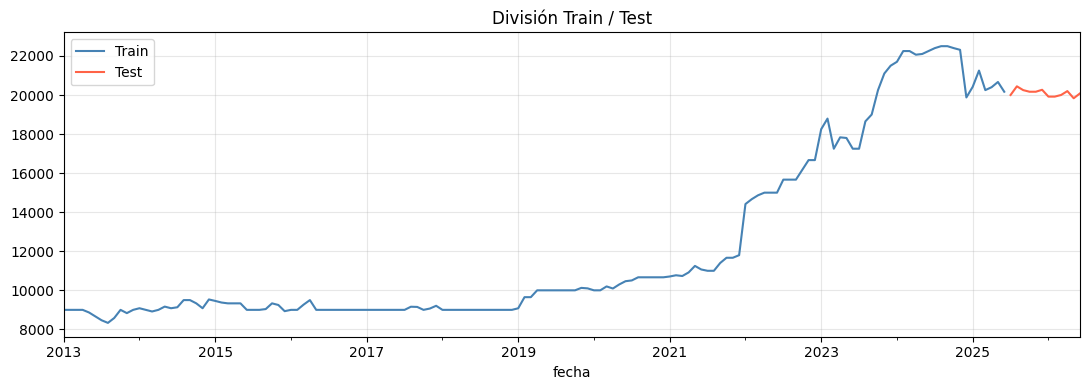

In [20]:
def fuerza_estacional(y, m=12):
    """Fs = max(0, 1 - Var(resid)/Var(resid+seasonal)) (Hyndman). >0.3 ~ estacionalidad fuerte."""
    if len(y) < 2*m + 1:
        return np.nan
    try:
        res = STL(y, period=m, robust=True).fit()
    except Exception:
        return np.nan
    var_r  = np.nanvar(res.resid)
    var_rs = np.nanvar(res.resid + res.seasonal)
    return float(max(0.0, 1 - var_r/var_rs)) if var_rs > 0 else 0.0


def fuerza_tendencia(y, m=12):
    """Ft = max(0, 1 - Var(resid)/Var(resid+trend)) (Hyndman)."""
    if len(y) < 2*m + 1:
        return np.nan
    try:
        res = STL(y, period=m, robust=True).fit()
    except Exception:
        return np.nan
    var_r  = np.nanvar(res.resid)
    var_rt = np.nanvar(res.resid + res.trend)
    return float(max(0.0, 1 - var_r/var_rt)) if var_rt > 0 else 0.0


def verificar_registros(y, m=12, etiqueta=''):
    """Diagnostico de tamano + limites de busqueda SARIMA.

    IMPORTANTE: el periodo estacional SIEMPRE es m=12 (ciclo anual de precios
    agricolas). Nunca se colapsa a m=0/1: si hay al menos 2 ciclos completos se
    habilita el bloque estacional (P,D,Q,12). La Fuerza estacional Fs solo sirve
    para informar y para decidir cuantos parametros estacionales permitir, no
    para apagar la estacionalidad.
    """
    n = int(y.dropna().shape[0])
    ciclos = n / m
    nivel = ('INSUFICIENTE' if n < 24 else 'MINIMO' if n < 36 else
             'ACEPTABLE' if n < 48 else 'BUENO' if n < 72 else 'OPTIMO')

    Fs = fuerza_estacional(y, m)
    Ft = fuerza_tendencia(y, m)
    # Con >= 2 ciclos ya se puede estimar un bloque estacional en m=12.
    seasonal_ok    = bool(n >= 2*m + 1)
    seasonal_fuerte = bool(seasonal_ok and np.isfinite(Fs) and Fs >= 0.30)
    tendencia_ok   = bool(np.isfinite(Ft) and Ft >= 0.30)

    presupuesto = max(4, n // 8)           # holgura para que quepa el bloque estacional
    max_p = 3 if n >= 60 else 2 if n >= 36 else 1
    max_q = max_p
    max_P = 1 if seasonal_ok else 0
    max_Q = 1 if (seasonal_ok and n >= 3*m) else 0
    h_bt = int(min(m, max(6, n // 5), max(3, n - max(3*m, 24))))

    info = dict(n=n, ciclos=round(ciclos, 2), nivel=nivel, apto=n >= 24, m=m,
                Fs=None if not np.isfinite(Fs) else round(Fs, 3),
                Ft=None if not np.isfinite(Ft) else round(Ft, 3),
                seasonal_ok=seasonal_ok, seasonal_fuerte=seasonal_fuerte,
                seasonal_debil=bool(seasonal_ok and not seasonal_fuerte),
                tendencia_ok=tendencia_ok,
                max_p=max_p, max_q=max_q, max_P=max_P, max_Q=max_Q,
                presupuesto=presupuesto, h_bt=h_bt)

    print(f"{etiqueta}Registros            : {n}")
    print(f"{etiqueta}Periodo estacional m : {m}  (fijo, ciclo anual)")
    print(f"{etiqueta}Ciclos (m={m})        : {ciclos:.2f}")
    print(f"{etiqueta}Nivel                : {nivel}")
    print(f"{etiqueta}Fuerza estacional Fs : {info['Fs']}  ({'fuerte' if seasonal_fuerte else 'moderada/debil'})")
    print(f"{etiqueta}Fuerza tendencia  Ft : {info['Ft']}  ({'con tendencia' if tendencia_ok else 'sin tendencia clara'})")
    print(f"{etiqueta}Bloque estacional    : {'SI (P,D,Q,12)' if seasonal_ok else 'NO (menos de 2 ciclos)'}")
    print(f"{etiqueta}Limites busqueda     : p<={max_p} q<={max_q} P<={max_P} Q<={max_Q} (max {presupuesto} params)")
    if not info['apto']:
        print(f'{etiqueta}ATENCION: serie insuficiente para modelar (<24).')
    return info


def dividir_train_test(y, test_size=None, m=12, min_train=None):
    """Divide la serie de forma cronologica (sin mezclar el orden temporal)."""
    n = len(y)
    min_train = min_train or max(3*m, 24)

    if test_size is None:
        test_size = int(min(m, max(6, n // 5), max(3, n - min_train)))
    test_size = max(1, min(test_size, n - min_train)) if n > min_train else max(1, n // 5)

    y_train = y.iloc[:-test_size]
    y_test  = y.iloc[-test_size:]

    print(f'Serie total   : {n} observaciones')
    print(f'Train         : {len(y_train)} observaciones '
          f'({y_train.index[0].strftime("%Y-%m")} a {y_train.index[-1].strftime("%Y-%m")})')
    print(f'Test          : {len(y_test)} observaciones '
          f'({y_test.index[0].strftime("%Y-%m")} a {y_test.index[-1].strftime("%Y-%m")})')
    return y_train, y_test


print('--- Serie completa (referencia) ---')
_ = verificar_registros(y, m=M)

y_train, y_test = dividir_train_test(y, test_size=TEST_SIZE, m=M)

print('\n--- Train (rige la busqueda de ordenes; el test queda fuera para no filtrarlo) ---')
info = verificar_registros(y_train, m=M, etiqueta='  ')

fig, ax = plt.subplots(figsize=(11, 4))
y_train.plot(ax=ax, label='Train', color='steelblue')
y_test.plot(ax=ax, label='Test', color='tomato')
ax.set_title('División Train / Test')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Fase 3 — Exploración, estacionariedad e identificación (train)

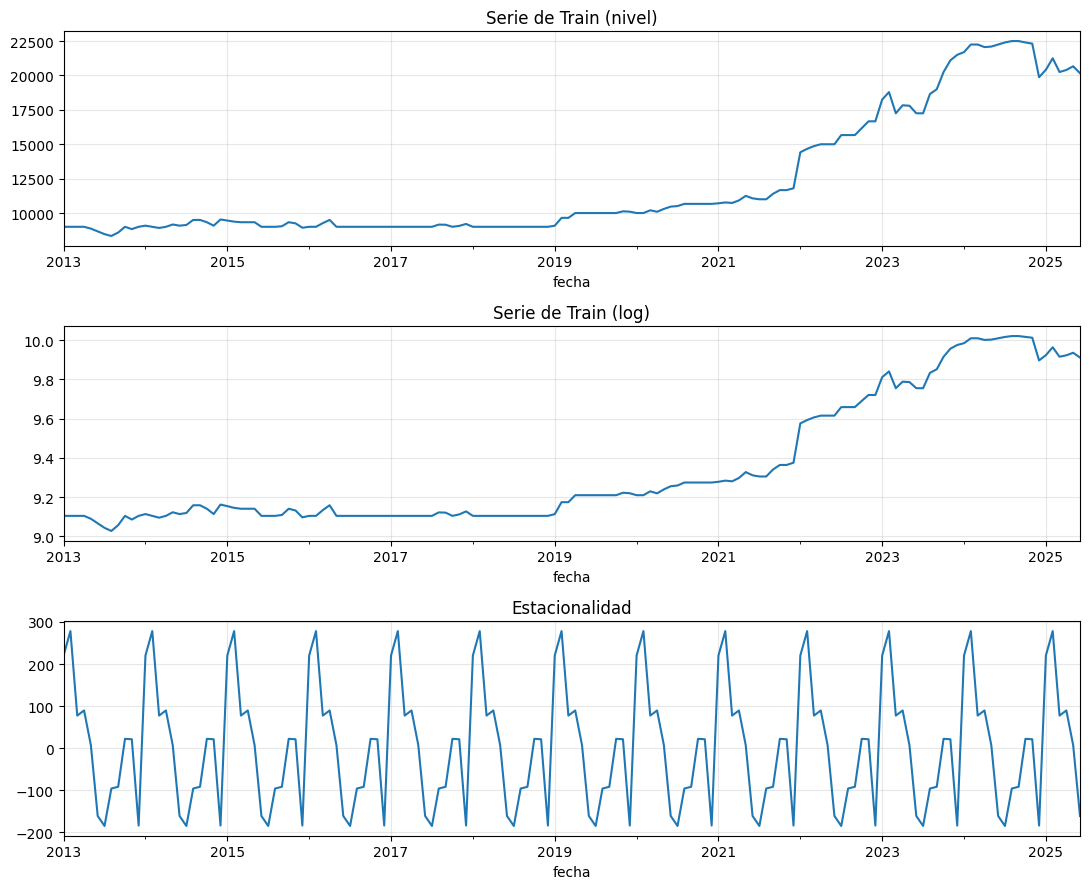

Amplitud estacional = 463.0 (3.8% del nivel medio)


In [21]:
fig, ax = plt.subplots(3, 1, figsize=(11, 9))
y_train.plot(ax=ax[0], title='Serie de Train (nivel)'); ax[0].grid(alpha=.3)
np.log(y_train).plot(ax=ax[1], title='Serie de Train (log)'); ax[1].grid(alpha=.3)
if len(y_train) >= 2*M:
    seasonal_decompose(y_train, model='additive', period=M).seasonal.plot(ax=ax[2], title='Estacionalidad')
    ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

if len(y_train) >= 2*M:
    est = seasonal_decompose(y_train, model='additive', period=M).seasonal
    print(f'Amplitud estacional = {est.max()-est.min():,.1f} '
          f'({(est.max()-est.min())/y_train.mean()*100:.1f}% del nivel medio)')

In [22]:
def detectar_outliers(y_serie, umbral=3.5):
    """Detecta variaciones mes a mes atipicas usando un z-score robusto
    (mediana + MAD) sobre las diferencias de primer orden."""
    diffs = y_serie.diff().dropna()
    mediana = diffs.median()
    mad = (diffs - mediana).abs().median()
    if mad == 0:
        return pd.Series(dtype=float)
    z = 0.6745 * (diffs - mediana) / mad
    return diffs[z.abs() > umbral]


atipicos_train = detectar_outliers(y_train)
if len(atipicos_train):
    print('Meses con variacion atipica en TRAIN (posibles choques puntuales):')
    for fecha, delta in atipicos_train.items():
        print(f'  {fecha.strftime("%Y-%m")}: variacion = {delta:+,.1f}')
else:
    print('No se detectaron variaciones atipicas relevantes en train.')

atipicos_test = detectar_outliers(pd.concat([y_train.tail(M), y_test]))
atipicos_test = atipicos_test[atipicos_test.index.isin(y_test.index)]
if len(atipicos_test):
    print('\nAVISO: el conjunto de TEST tiene meses con variacion atipica; es esperable que el error del modelo suba ahi:')
    for fecha, delta in atipicos_test.items():
        print(f'  {fecha.strftime("%Y-%m")}: variacion = {delta:+,.1f}')

USE_LOG = True     # transformacion logaritmica para estabilizar varianza (exige precios > 0)

Meses con variacion atipica en TRAIN (posibles choques puntuales):
  2014-12: variacion = +450.0
  2016-05: variacion = -500.0
  2019-02: variacion = +570.0
  2022-01: variacion = +2,617.0
  2022-07: variacion = +667.0
  2022-10: variacion = +500.0
  2022-11: variacion = +500.0
  2023-01: variacion = +1,583.0
  2023-02: variacion = +542.0
  2023-03: variacion = -1,542.0
  2023-04: variacion = +583.0
  2023-06: variacion = -550.0
  2023-08: variacion = +1,400.0
  2023-10: variacion = +1,250.0
  2023-11: variacion = +850.0
  2024-02: variacion = +550.0
  2024-12: variacion = -2,438.0
  2025-01: variacion = +542.0
  2025-02: variacion = +833.0
  2025-03: variacion = -1,000.0
  2025-06: variacion = -500.0


In [23]:
def test_estacionariedad(x, nombre=''):
    x = pd.Series(x).dropna()
    if len(x) < 8:
        print(f'{nombre}: muestra insuficiente ({len(x)})'); return None, None
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', InterpolationWarning)
        adf = adfuller(x)[1]
        kps = kpss(x, nlags='auto')[1]
    print(f'{nombre}: ADF p={adf:.3f}  KPSS p={kps:.3f}')
    return adf, kps


y_mod_train = np.log(y_train) if USE_LOG else y_train.copy()

test_estacionariedad(y_mod_train, 'nivel (train)')
test_estacionariedad(y_mod_train.diff(), 'd=1 (train)')
if len(y_mod_train) > M + 4:
    test_estacionariedad(y_mod_train.diff(M), 'D=1 estacional (train)')


def estimar_dD(ys, info, m=12):
    """d se estima con KPSS. D estacional: se PRIORIZA D=1 siempre que queden
    suficientes observaciones utiles, porque es lo que hace que el modelo
    arrastre el patron anual (y no un pronostico plano). Solo se deja D=0 si
    el test OCSB lo rechaza con estacionalidad claramente debil."""
    if HAS_PMDARIMA:
        d = int(min(2, ndiffs(ys, test='kpss', max_d=2)))
    else:
        adf = test_estacionariedad(ys, '_')[0]
        d = 0 if (adf is not None and adf < 0.05) else 1

    D = 0
    if info['seasonal_ok']:
        D = 1
        if HAS_PMDARIMA and not info['seasonal_fuerte']:
            try:
                D = int(min(1, nsdiffs(ys, m=m, max_D=1, test='ocsb')))
            except Exception:
                D = 1
        # nunca dejar menos de 1.5 ciclos utiles tras diferenciar
        if len(ys) - D*m - d < int(1.5*m):
            D = 0
    print(f'Diferenciacion estimada (train) -> d={d}, D={D} (m={m})')
    if info['seasonal_ok'] and D == 0:
        print('  (D=0: la estacionalidad se modelara con terminos AR/MA estacionales P/Q en m=12)')
    return d, D


D_ORDER, D_SEAS = estimar_dD(y_mod_train, info, M)

nivel (train): ADF p=0.978  KPSS p=0.010
d=1 (train): ADF p=0.000  KPSS p=0.079
D=1 estacional (train): ADF p=0.668  KPSS p=0.010
Diferenciacion estimada (train) -> d=1, D=0 (m=12)
  (D=0: la estacionalidad se modelara con terminos AR/MA estacionales P/Q en m=12)


n efectivo tras diferenciar (train) = 149 | lags = 36


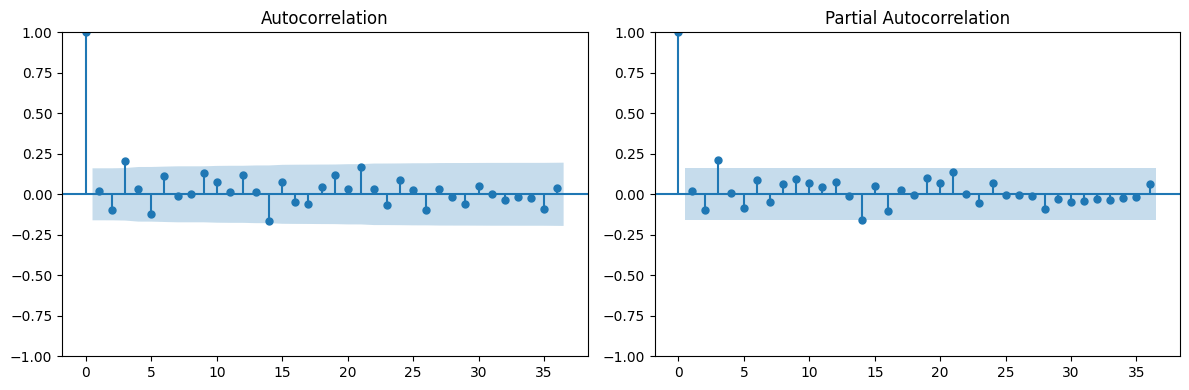

ACF(lag 12) = 0.133


In [24]:
yd = y_mod_train.copy()
for _ in range(D_ORDER): yd = yd.diff()
for _ in range(D_SEAS):  yd = yd.diff(M)
yd = yd.dropna()

n = len(yd)
lags = max(4, min(36, (n // 2) - 1))
print(f'n efectivo tras diferenciar (train) = {n} | lags = {lags}')
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(yd, lags=lags, ax=ax[0]); plot_pacf(yd, lags=lags, method='ywm', ax=ax[1])
plt.tight_layout(); plt.show()

if len(yd) > M:
    acf_m = pd.Series(yd).autocorr(lag=M)
    print(f'ACF(lag {M}) = {acf_m:.3f}' +
          ('  <-- posible SOBRE-diferenciacion estacional (revisa D)' if acf_m < -0.35 else ''))

## Fase 4 — Estimación del modelo y diagnóstico de residuos (train)

In [26]:
FIT_KW = dict(enforce_stationarity=True, enforce_invertibility=True, maxiter=300, method='powell')


def _fit(ys, order, sorder, trend=None):
    return SARIMAX(ys, order=order, seasonal_order=sorder, trend=trend, **FIT_KW).fit(disp=False)


def modelo_estable(fit):
    """True si todas las raices AR (y estacionales) estan fuera del circulo unitario."""
    try:
        ar = np.concatenate([np.atleast_1d(fit.arroots), np.atleast_1d(getattr(fit, 'seasonalarroots', []))])
        return bool(len(ar) == 0 or np.all(np.abs(ar) > 1.01))
    except Exception:
        return True


def _sanear_sorder(sorder, D, m=12, seasonal=True):
    """Garantiza que el bloque estacional NUNCA quede en (0,0,0,0) ni con s=0.
    Si la busqueda devuelve todo ceros, se impone al menos un termino en m=12."""
    if not seasonal:
        return (0, 0, 0, 0)
    P, Dd, Q, s = (list(sorder) + [0, 0, 0, 0])[:4]
    s = m                       # el periodo estacional SIEMPRE es m (=12)
    Dd = int(Dd if Dd else D)
    if P == 0 and Q == 0 and Dd == 0:
        Q = 1                   # MA estacional minimo: mantiene el patron anual
    return (int(P), int(Dd), int(Q), int(s))


def ajustar_sarima(ys, info, d, D, m=12, verbose=True):
    """ys ya viene en la escala de modelado (log si USE_LOG). Solo datos de train.
    La busqueda es SIEMPRE estacional con m=12 cuando hay >= 2 ciclos."""
    seasonal = bool(info['seasonal_ok'])
    max_p, max_q = info['max_p'], info['max_q']
    max_P = max(1, info['max_P']) if seasonal else 0
    max_Q = max(1, info['max_Q']) if seasonal else 0

    order, sorder = (1, d, 0), _sanear_sorder((1, D, 0, m), D, m, seasonal)
    if HAS_PMDARIMA:
        try:
            mdl = pm.auto_arima(ys, seasonal=seasonal, m=m if seasonal else 1,
                                d=d, D=D if seasonal else 0,
                                start_p=0, start_q=0, start_P=0, start_Q=1,
                                max_p=max_p, max_q=max_q, max_P=max_P, max_Q=max_Q,
                                information_criterion='aicc',
                                stationary=False, stepwise=True,
                                suppress_warnings=True, error_action='ignore', trace=False)
            order  = mdl.order
            sorder = _sanear_sorder(mdl.seasonal_order, D, m, seasonal)
            if seasonal and sorder[0] == 0 and sorder[2] == 0 and sorder[1] == 0:
                D_forzado = max(1, D)
                sorder = (0, D_forzado, 1, m)
                if verbose: print(f'auto_arima sin terminos estacionales -> forzado sorder={sorder}')
        except Exception as e:
            if verbose: print('auto_arima fallo, uso fallback:', e)
    else:
        mejor, best = None, np.inf
        for p in range(max_p+1):
            for q in range(max_q+1):
                for P in range(max_P+1):
                    for Q in range(max_Q+1):
                        so = _sanear_sorder((P, D, Q, m), D, m, seasonal)
                        try:
                            f = _fit(ys, (p, d, q), so)
                            if f.aicc < best and modelo_estable(f):
                                best, mejor = f.aicc, ((p, d, q), so)
                        except Exception:
                            continue
        if mejor: order, sorder = mejor

    k = order[0] + order[2] + sorder[0] + sorder[2]
    if k > info['presupuesto']:
        if verbose: print(f'Modelo simplificado: k={k} > presupuesto={info["presupuesto"]}')
        order  = (1, d, 0)
        sorder = _sanear_sorder((1, D, 0, m), D, m, seasonal)

    try:
        if not modelo_estable(_fit(ys, order, sorder)):
            if verbose: print('Modelo inestable -> degradado a (0,d,1)(0,D,1)[m]')
            order  = (0, d, 1)
            sorder = _sanear_sorder((0, D, 1, m), D, m, seasonal)
    except Exception:
        order  = (0, d, 1)
        sorder = _sanear_sorder((0, D, 1, m), D, m, seasonal)
    return order, sorder


order, seasonal_order = ajustar_sarima(y_mod_train, info, D_ORDER, D_SEAS, M)
print('order =', order, '| seasonal_order =', seasonal_order, '| use_log =', USE_LOG)
if seasonal_order[3] != M:
    print('AVISO: se forzo el periodo estacional a m =', M)
    seasonal_order = (seasonal_order[0], seasonal_order[1], seasonal_order[2], M)
if info['seasonal_ok'] and seasonal_order[0] == 0 and seasonal_order[2] == 0 and seasonal_order[1] == 0:
    seasonal_order = (0, max(1, D_SEAS), 1, M)
    print(f'AVISO: modelo sin terminos estacionales -> corregido a seasonal_order={seasonal_order}')


order = (0, 1, 0) | seasonal_order = (1, 0, 0, 12) | use_log = True


                                     SARIMAX Results                                      
Dep. Variable:                             precio   No. Observations:                  150
Model:             SARIMAX(0, 1, 0)x(1, 0, 0, 12)   Log Likelihood                 317.564
Date:                            Wed, 19 Aug 2026   AIC                           -631.129
Time:                                    07:04:14   BIC                           -625.121
Sample:                                01-01-2013   HQIC                          -628.688
                                     - 06-01-2025                                         
Covariance Type:                              opg                                         
Modelo estable (raices AR fuera del circulo): True
residuos utiles = 149 | lags diagnostico = 24


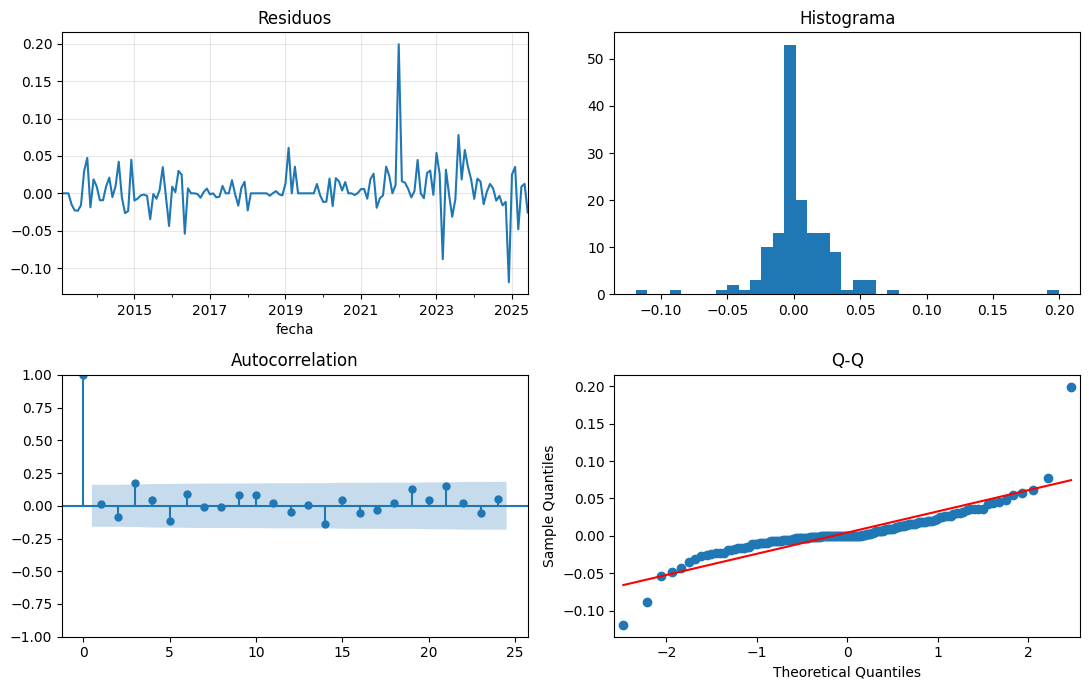

      lb_stat  lb_pvalue
10  11.630621   0.310538
Ruido blanco (p>0.05): True
Jarque-Bera p = 0.0


In [27]:
fit_train = _fit(y_mod_train, order, seasonal_order)
print(fit_train.summary().tables[0])
print('Modelo estable (raices AR fuera del circulo):', modelo_estable(fit_train))

resid = pd.Series(fit_train.resid).replace([np.inf, -np.inf], np.nan).dropna()
burn = order[1] + seasonal_order[1]*(seasonal_order[3] or 0)
resid = resid.iloc[burn:]
nr = len(resid)
lags_r = max(2, min(24, (nr // 2) - 1))
print(f'residuos utiles = {nr} | lags diagnostico = {lags_r}')

if nr >= 8:
    fig, ax = plt.subplots(2, 2, figsize=(11, 7))
    resid.plot(ax=ax[0,0], title='Residuos'); ax[0,0].grid(alpha=.3)
    ax[0,1].hist(resid, bins=max(5, nr//4)); ax[0,1].set_title('Histograma')
    plot_acf(resid, lags=lags_r, ax=ax[1,0])
    qqplot(resid, line='s', ax=ax[1,1]); ax[1,1].set_title('Q-Q')
    plt.tight_layout(); plt.show()
    lb = acorr_ljungbox(resid, lags=[max(1, min(lags_r, 10))], return_df=True)
    print(lb)
    print('Ruido blanco (p>0.05):', bool(lb['lb_pvalue'].iloc[0] > 0.05))
    print('Jarque-Bera p =', round(stats.jarque_bera(resid)[1], 4))
else:
    print('Muy pocos residuos para diagnostico grafico.')

## Fase 5 — Evaluación en Test (backtest rolling-origin) + métricas

In [29]:
def _inv_log(mu, var=None, use_log=True):
    """Vuelve a la escala original. Con log se aplica correccion de sesgo
    exp(mu + var/2) => se estima la MEDIA condicional, no la mediana."""
    mu = np.asarray(mu, float)
    if not use_log:
        return mu
    if var is None:
        return np.exp(mu)
    return np.exp(mu + np.asarray(var, float) / 2.0)


def _mase_denom(y_hist, m=12):
    yt = np.asarray(y_hist, float)
    lag = m if len(yt) > m + 2 else 1
    return np.mean(np.abs(yt[lag:] - yt[:-lag])) if len(yt) > lag else np.nan


def _metricas(y_true, y_pred, denom):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    err = y_true - y_pred
    mae   = np.mean(np.abs(err))
    rmse  = np.sqrt(np.mean(err**2))
    mape  = np.mean(np.abs(err / y_true)) * 100
    smape = np.mean(2*np.abs(err) / (np.abs(y_true) + np.abs(y_pred))) * 100
    mase  = mae/denom if denom and np.isfinite(denom) and denom > 0 else np.nan
    return dict(MAE=mae, RMSE=rmse, MAPE=mape, sMAPE=smape, MASE=mase,
                Accuracy=max(0.0, 100 - mape))


def make_sarimax_predictor(order, sorder, trend=None):
    def _p(y_hist, steps, want_full=False):
        ym = np.log(y_hist) if USE_LOG else y_hist
        f = SARIMAX(ym, order=order, seasonal_order=sorder, trend=trend, **FIT_KW).fit(disp=False)
        fc = f.get_forecast(steps=steps)
        try:
            var = np.asarray(fc.var_pred_mean, float)
        except Exception:
            var = None
        punto = _inv_log(fc.predicted_mean.values, var, USE_LOG)
        if not want_full:
            return punto
        ci = fc.conf_int(alpha=0.05)
        lo = np.exp(ci.iloc[:, 0].values) if USE_LOG else ci.iloc[:, 0].values
        hi = np.exp(ci.iloc[:, 1].values) if USE_LOG else ci.iloc[:, 1].values
        return punto, lo, hi, f
    return _p


def make_snaive(m=12):
    def _p(y_hist, steps, want_full=False):
        last = np.asarray(y_hist.iloc[-m:], float)
        p = np.array([last[i % len(last)] for i in range(steps)], float)
        return (p, None, None, None) if want_full else p
    return _p


def make_drift(ventana=None):
    """Naive con deriva: extiende la pendiente media reciente.
    Es la referencia MINIMA que un pronostico util debe batir y NUNCA es plano."""
    def _p(y_hist, steps, want_full=False):
        v = len(y_hist) if ventana is None else min(ventana, len(y_hist))
        z = y_hist.iloc[-v:]
        slope = (float(z.iloc[-1]) - float(z.iloc[0])) / max(1, len(z) - 1)
        p = float(y_hist.iloc[-1]) + slope * np.arange(1, steps + 1)
        return (p, None, None, None) if want_full else p
    return _p


def backtest_rolling(y, predictor, h, min_train, max_origenes=6, m=12):
    """Reestima el modelo en varios origenes y pronostica el horizonte COMPLETO h.
    Evalua exactamente el uso real (h meses de un tiron, varias veces)."""
    n = len(y)
    ultimos = n - h
    if ultimos < min_train:
        min_train = max(m + 2, int(n * 0.6))
    origenes = [o for o in range(min_train, ultimos + 1)]
    if not origenes:
        origenes = [max(m + 2, n - max(1, h // 2))]
    if len(origenes) > max_origenes:
        idx = np.unique(np.linspace(0, len(origenes) - 1, max_origenes).round().astype(int))
        origenes = [origenes[i] for i in idx]

    filas, err_h, trayectorias = [], {k: [] for k in range(1, h + 1)}, {}
    for o in origenes:
        y_hist = y.iloc[:o]
        steps = min(h, n - o)
        if steps < 1:
            continue
        y_real = y.iloc[o:o + steps]
        try:
            pred = np.asarray(predictor(y_hist, steps), float)
            if not np.all(np.isfinite(pred)):
                raise ValueError('pronostico no finito')
        except Exception:
            pred = np.repeat(float(y_hist.iloc[-1]), steps)
        denom = _mase_denom(y_hist, m)
        met = _metricas(y_real.values, pred, denom)
        met['origen'] = y_hist.index[-1].strftime('%Y-%m'); met['h'] = steps
        filas.append(met)
        trayectorias[y_hist.index[-1]] = pd.Series(pred, index=y_real.index)
        for k in range(steps):
            if denom and np.isfinite(denom) and denom > 0:
                err_h[k + 1].append(abs(y_real.values[k] - pred[k]) / denom)

    detalle = pd.DataFrame(filas)
    glob = {c: float(np.nanmean(detalle[c])) for c in
            ['MAE', 'RMSE', 'MAPE', 'sMAPE', 'MASE', 'Accuracy']}
    perfil = pd.Series({k: (np.mean(v) if v else np.nan) for k, v in err_h.items()},
                       name='MASE_por_horizonte')
    return glob, perfil, detalle, trayectorias


def planitud(pred):
    """Mide que tan 'plano' es un pronostico: rango relativo respecto al nivel.
    ~0 => linea recta constante (sintoma del problema reportado)."""
    p = np.asarray(pred, float)
    return float((p.max() - p.min()) / max(1e-9, np.mean(np.abs(p))))


# --- Conjunto de candidatos: familia ARIMA / SARIMA, periodo estacional m=12 ---
order_ns = (order[0], order[1], order[2])
d_o = order[1]
D_s = int(seasonal_order[1]) if seasonal_order[1] else (1 if info['seasonal_ok'] and len(y) >= 3*M else 0)
# Con d>=1, trend='t' equivale a DERIVA en el nivel: mantiene la TENDENCIA
# y evita que el pronostico se aplane en una recta horizontal.
TREND_DERIVA = 't' if d_o >= 1 else 'c'

def S(P, D_, Q):
    """Todo bloque estacional se construye SIEMPRE con periodo M (=12)."""
    return (int(P), int(D_), int(Q), int(M))

CANDIDATOS = {}
if info['seasonal_ok']:
    CANDIDATOS['SARIMA auto']                = dict(kind='sarimax', order=order, sorder=S(*seasonal_order[:3]), trend=None)
    CANDIDATOS['SARIMA auto + deriva']       = dict(kind='sarimax', order=order, sorder=S(*seasonal_order[:3]), trend=TREND_DERIVA)
    CANDIDATOS['SARIMA(0,1,1)(0,1,1)[12]']   = dict(kind='sarimax', order=(0,1,1), sorder=S(0,1,1), trend=None)
    CANDIDATOS['SARIMA(0,1,1)(0,1,1)[12] + deriva'] = dict(kind='sarimax', order=(0,1,1), sorder=S(0,1,1), trend='t')
    CANDIDATOS['SARIMA(1,1,1)(0,1,1)[12] + deriva'] = dict(kind='sarimax', order=(1,1,1), sorder=S(0,1,1), trend='t')
    CANDIDATOS['SARIMA(1,1,0)(1,1,0)[12]']   = dict(kind='sarimax', order=(1,1,0), sorder=S(1,1,0), trend=None)
    CANDIDATOS['SARIMA(1,1,1)(1,0,1)[12] + deriva'] = dict(kind='sarimax', order=(1,1,1), sorder=S(1,0,1), trend='t')
    CANDIDATOS['SARIMA(0,1,1)(1,0,0)[12] + deriva'] = dict(kind='sarimax', order=(0,1,1), sorder=S(1,0,0), trend='t')
    CANDIDATOS['SARIMA(0,1,1)(1,1,1)[12] + deriva'] = dict(kind='sarimax', order=(0,1,1), sorder=S(1,1,1), trend='t')
    CANDIDATOS['SARIMA(1,1,1)(1,1,1)[12]']   = dict(kind='sarimax', order=(1,1,1), sorder=S(1,1,1), trend=None)
    CANDIDATOS['SARIMA(0,1,1)(1,1,0)[12]']   = dict(kind='sarimax', order=(0,1,1), sorder=S(1,1,0), trend=None)
    CANDIDATOS['SARIMA(1,1,0)(0,1,1)[12] + deriva'] = dict(kind='sarimax', order=(1,1,0), sorder=S(0,1,1), trend='t')
# Controles NO estacionales (para comprobar que la estacionalidad aporta)
CANDIDATOS['ARIMA auto (control, sin estacional)'] = dict(kind='sarimax', order=order_ns, sorder=(0,0,0,0), trend=None)
CANDIDATOS['ARIMA(1,1,1) + deriva (control)']      = dict(kind='sarimax', order=(1,1,1), sorder=(0,0,0,0), trend='t')

# Referencia (NO compite): el naive estacional es el denominador del MASE.
REFERENCIAS = {'Naive estacional': make_snaive(M), 'Deriva (12m)': make_drift(12)}


def amplitud_estacional_pred(pred, m=12):
    """Cuanta forma anual tiene el pronostico: desviacion del pronostico una vez
    quitada su recta de tendencia, relativa al nivel. ~0 => recta sin estacionalidad."""
    p = np.asarray(pred, float)
    if len(p) < 3:
        return np.nan
    x = np.arange(len(p))
    coef = np.polyfit(x, p, 1)
    resid = p - np.polyval(coef, x)
    return float(np.std(resid) / max(1e-9, np.mean(np.abs(p))))


def pendiente_rel(pred):
    """Tendencia del pronostico (cambio total relativo de la recta ajustada)."""
    p = np.asarray(pred, float)
    if len(p) < 2:
        return np.nan
    x = np.arange(len(p))
    m_, b_ = np.polyfit(x, p, 1)
    return float(m_ * (len(p) - 1) / max(1e-9, np.mean(np.abs(p))))


def construir_predictor(spec):
    k = spec['kind']
    if k == 'sarimax':
        return make_sarimax_predictor(spec['order'], spec['sorder'], spec.get('trend'))
    if k == 'snaive':
        return make_snaive(M)
    if k == 'drift':
        return make_drift(spec.get('ventana'))
    raise ValueError(k)


PREDICTORES = {n: construir_predictor(s) for n, s in CANDIDATOS.items()}

# --- Ejecucion del backtest rolling-origin ---------------------------------
H_TEST    = len(y_test)
H_EVAL    = int(min(H_FUTURO, max(3, H_TEST)))
MIN_TRAIN = max(2*M + 2, int(len(y) * 0.6))

resultados, perfiles, curvas_test, detalles = {}, {}, {}, {}
N_ORIGENES = 6
for nombre, pred_fn in PREDICTORES.items():
    try:
        glob, perfil, det, _tray = backtest_rolling(y, pred_fn, H_EVAL, MIN_TRAIN,
                                                     max_origenes=N_ORIGENES, m=M)
        resultados[nombre] = glob
        perfiles[nombre]   = perfil
        detalles[nombre]   = det
    except Exception as e:
        print(f'{nombre}: fallo en backtest ({e})')
        continue
    try:
        curva = np.asarray(pred_fn(y_train, H_TEST), float)
        curvas_test[nombre] = curva
        resultados[nombre]['Planitud']  = planitud(curva)
        resultados[nombre]['Estacion']  = amplitud_estacional_pred(curva, M)
        resultados[nombre]['Tendencia'] = pendiente_rel(curva)
    except Exception:
        resultados[nombre]['Planitud']  = np.nan
        resultados[nombre]['Estacion']  = np.nan
        resultados[nombre]['Tendencia'] = np.nan
    resultados[nombre]['Estacional'] = bool(CANDIDATOS[nombre]['sorder'][3] == M)

cols = ['MAE', 'RMSE', 'MAPE', 'sMAPE', 'MASE', 'Accuracy', 'Planitud', 'Estacion', 'Tendencia', 'Estacional']
comparativa = pd.DataFrame(resultados).T[cols].sort_values('MASE')
perfil_horizonte = pd.DataFrame(perfiles)

print(f'Familia ARIMA / SARIMA con periodo estacional fijo m={M}.')
print(f'=== BACKTEST ROLLING-ORIGIN (h={H_EVAL} meses, {len(detalles[list(detalles)[0]])} origenes, '
      f'{len(CANDIDATOS)} candidatos) ===')
print('Planitud = variacion total del pronostico | Estacion = forma anual | Tendencia = pendiente relativa')
print(comparativa.round(3).to_string())

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Familia ARIMA / SARIMA con periodo estacional fijo m=12.
=== BACKTEST ROLLING-ORIGIN (h=12 meses, 6 origenes, 14 candidatos) ===
Planitud = variacion total del pronostico | Estacion = forma anual | Tendencia = pendiente relativa
                                              MAE         RMSE       MAPE      sMAPE      MASE   Accuracy  Planitud  Estacion Tendencia Estacional
SARIMA(1,1,1)(1,1,1)[12]              1737.423217  1999.738792   9.646595   9.739556  2.569153  90.353405  0.097367  0.013173  0.090185       True
SARIMA(0,1,1)(1,0,0)[12] + deriva     1808.999827  2074.248339   9.914202   9.880974  2.588444  90.085798  0.078284  0.005383  0.074822       True
ARIMA(1,1,1) + deriva (control)       1800.573599  2098.939006   9.899765   9.958578  2.589098  90.100235  0.133543  0.001173  0.133468      False
SARIMA auto + deriva                  1814.725121  2078.211063   9.960549   9.948329  2.609503  90.039451  0.076999  0.005379  0.073538       True
SARIMA(0,1,1)(0,1,1)[12]            

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Fase 6 — Selección del modelo ganador y validación visual

In [30]:
UMBRAL_PLANITUD = 0.005
UMBRAL_ESTACION = 0.004      # forma anual minima para considerar que "usa" la estacionalidad
AMPLITUD_MINIMA = 0.01       # 1%: amplitud minima del pronostico para no ser considerado 'plano'
TOLERANCIA = 0.10            # 10%: modelos dentro de este margen del mejor MASE son equivalentes

mov_real = planitud(y.iloc[-min(len(y), 24):].values)

cand = comparativa.copy()
cand['degenerado'] = (cand['Planitud'] < UMBRAL_PLANITUD) & (mov_real > 5 * UMBRAL_PLANITUD)

crit = 'MASE' if cand['MASE'].notna().any() else 'MAE'
utiles = cand[~cand['degenerado']]
if not len(utiles):
    utiles = cand
    print('AVISO: todos los candidatos son planos; la serie parece una caminata aleatoria pura.')

mejor_valor = float(utiles[crit].min())
empate = utiles[utiles[crit] <= mejor_valor * (1 + TOLERANCIA)]

# Entre modelos estadisticamente equivalentes se prefiere el que SI captura
# estacionalidad (m=12) y trayectoria; asi el pronostico deja de ser una recta.
preferidos = empate[(empate['Estacional'] == True) & (empate['Estacion'] >= UMBRAL_ESTACION)]
if len(preferidos):
    GANADOR = preferidos[crit].idxmin()
else:
    GANADOR = empate[crit].idxmin()

# Blindaje: si el ganador tiene amplitud estacional muy baja, buscar uno mejor
if cand.loc[GANADOR, 'Estacion'] < AMPLITUD_MINIMA:
    # Buscar entre todos los estacionales con amplitud suficiente
    con_amplitud = cand[(cand['Estacional'] == True) & (cand['Estacion'] >= AMPLITUD_MINIMA)]
    if len(con_amplitud):
        mejor_amp = con_amplitud[crit].idxmin()
        margen_amp = (cand.loc[mejor_amp, crit] - mejor_valor) / max(1e-9, mejor_valor)
        if margen_amp < 0.25:  # hasta 25% peor en MASE se acepta si gana amplitud
            print(f'GANADOR "{GANADOR}" tenia amplitud={cand.loc[GANADOR, "Estacion"]*100:.2f}% '
                  f'< {AMPLITUD_MINIMA*100:.1f}% -> reemplazado por "{mejor_amp}" '
                  f'(amplitud={cand.loc[mejor_amp, "Estacion"]*100:.2f}%, MASE +{margen_amp*100:.1f}%)')
            GANADOR = mejor_amp
    else:
        # Si ninguno tiene amplitud suficiente, intentar con tolerancia mas amplia
        amplio = cand[crit] <= mejor_valor * 1.50  # 50% de tolerancia
        con_amp_amplio = cand[amplio & (cand['Estacional'] == True) & (cand['Estacion'] >= AMPLITUD_MINIMA)]
        if len(con_amp_amplio):
            GANADOR = con_amp_amplio[crit].idxmin()
            print(f'GANADOR ajustado a "{GANADOR}" (tolerancia ampliada, amplitud={cand.loc[GANADOR, "Estacion"]*100:.2f}%)')

mejor_global = cand[crit].idxmin()
if mejor_global != GANADOR:
    margen = (cand.loc[GANADOR, crit] - cand.loc[mejor_global, crit]) / max(1e-9, cand.loc[mejor_global, crit])
    print(f'NOTA: "{mejor_global}" tiene el mejor {crit} bruto, pero se elige "{GANADOR}" '
          f'(solo {margen*100:.1f}% peor) porque modela estacionalidad m={M} y tendencia.')

mase_g = float(cand.loc[GANADOR, 'MASE'])
acc_g  = float(cand.loc[GANADOR, 'Accuracy'])
spec_g = CANDIDATOS[GANADOR]

print('=' * 74)
print(f'MEJOR VARIANTE: {GANADOR}')
print(f'  {crit}={cand.loc[GANADOR, crit]:.3f} | Accuracy={acc_g:.1f}% | '
      f'variacion={cand.loc[GANADOR, "Planitud"]*100:.2f}% | '
      f'forma anual={cand.loc[GANADOR, "Estacion"]*100:.2f}% | '
      f'tendencia={cand.loc[GANADOR, "Tendencia"]*100:+.2f}%')
print(f'  order={spec_g["order"]}  seasonal_order={spec_g["sorder"]}  trend={spec_g.get("trend")}')
print('=' * 74)

if np.isfinite(mase_g):
    if mase_g < 0.8:   veredicto = 'Aporta valor claro sobre el naive estacional (MASE<0.8).'
    elif mase_g < 1.0: veredicto = 'Mejora marginal sobre el naive; util pero con poco margen.'
    else:              veredicto = 'NO supera al naive estacional: la serie es poco predecible a este horizonte.'
    print(f'MASE rolling-origin = {mase_g:.3f} -> {veredicto}')

planos = cand.index[cand['degenerado']].tolist()
if planos:
    print('Variantes descartadas por pronostico plano:', ', '.join(planos))

MEJOR VARIANTE: SARIMA(1,1,1)(1,1,1)[12]
  MASE=2.569 | Accuracy=90.4% | variacion=9.74% | forma anual=1.32% | tendencia=+9.02%
  order=(1, 1, 1)  seasonal_order=(1, 1, 1, 12)  trend=None
MASE rolling-origin = 2.569 -> NO supera al naive estacional: la serie es poco predecible a este horizonte.
Variantes descartadas por pronostico plano: ARIMA auto (control, sin estacional)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

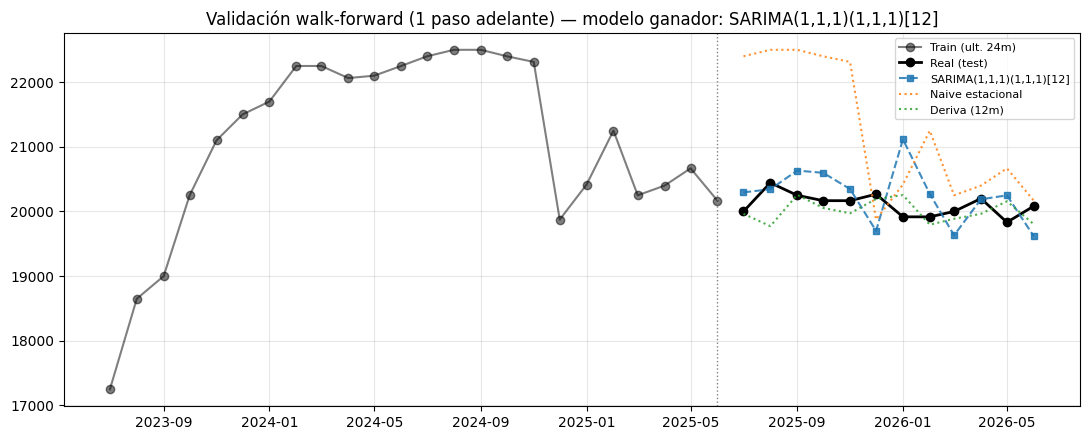

In [31]:
def backtest_walkforward_1paso(y, n_train, predictor):
    n_test = len(y) - n_train
    preds = []
    for i in range(n_test):
        y_hist = y.iloc[: n_train + i]
        try:
            p = predictor(y_hist, 1)
            val = float(np.asarray(p, float)[0])
            if not np.isfinite(val):
                raise ValueError('pronostico no finito')
        except Exception:
            val = float(y_hist.iloc[-1])
        preds.append(val)
    return np.array(preds)


n_train = len(y_train)
curvas_walkforward = {GANADOR: backtest_walkforward_1paso(y, n_train, PREDICTORES[GANADOR])}
for nombre, pred_fn in REFERENCIAS.items():
    try:
        curvas_walkforward[nombre] = backtest_walkforward_1paso(y, n_train, pred_fn)
    except Exception as e:
        print(f'{nombre}: fallo en walk-forward 1 paso ({e})')

plt.figure(figsize=(11, 4.5))
plt.plot(y_train.index[-24:], y_train.values[-24:], 'ko-', lw=1.5, alpha=.5, label='Train (ult. 24m)')
plt.plot(y_test.index, y_test.values, 'ko-', lw=2, label='Real (test)')
for nom, pred in curvas_walkforward.items():
    estilo = '--s' if nom == GANADOR else ':'
    plt.plot(y_test.index, pred, estilo, ms=4, alpha=.85, label=nom)
plt.axvline(y_train.index[-1], color='gray', ls=':', lw=1)
plt.title(f'Validación walk-forward (1 paso adelante) — modelo ganador: {GANADOR}')
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## Fase 7 — Reentrenamiento con la serie completa

In [32]:
y_mod_full = np.log(y) if USE_LOG else y.copy()
info_full = verificar_registros(y, M)

order_final, sorder_final, TREND_FINAL = spec_g['order'], spec_g['sorder'], spec_g.get('trend')

# Blindaje: si el ganador trae un bloque estacional mal formado (s=0) pero la
# serie admite estacionalidad, se restituye el periodo m=12.
if info_full['seasonal_ok'] and sorder_final[3] not in (0, M):
    sorder_final = (sorder_final[0], sorder_final[1], sorder_final[2], M)
if info_full['seasonal_ok']:
    if sorder_final[3] == 0:
        sorder_final = (sorder_final[0], sorder_final[1], sorder_final[2], M)
    if sorder_final[0] == 0 and sorder_final[2] == 0 and sorder_final[1] == 0:
        order_final = order_final if order_final[1] > 0 else (0, 1, 1)
        sorder_final = (0, 1, 1, M)
        TREND_FINAL = 't'
        print(f'AVISO Fase 7: sin terminos estacionales -> forzado {order_final} {sorder_final} trend={TREND_FINAL}')

def _ajustar(o, so, tr):
    return SARIMAX(y_mod_full, order=o, seasonal_order=so, trend=tr, **FIT_KW).fit(disp=False)

fit_full = _ajustar(order_final, sorder_final, TREND_FINAL)

if not modelo_estable(fit_full):
    print('AVISO: modelo inestable con la serie completa -> fallback estacional')
    if info_full['seasonal_ok']:
        order_final, sorder_final, TREND_FINAL = (0, 1, 1), (0, 1, 1, M), 't'
    else:
        order_final, sorder_final, TREND_FINAL = (0, 1, 1), (0, 0, 0, 0), 't'
    fit_full = _ajustar(order_final, sorder_final, TREND_FINAL)

predictor_final = make_sarimax_predictor(order_final, sorder_final, TREND_FINAL)

print(f'Reentrenado "{GANADOR}" con la serie completa ({len(y)} meses): '
      f'order={order_final}, seasonal_order={sorder_final}, trend={TREND_FINAL}')
print(f'Periodo estacional usado: m={sorder_final[3] if sorder_final[3] else "sin componente estacional"}')

Registros            : 162
Periodo estacional m : 12  (fijo, ciclo anual)
Ciclos (m=12)        : 13.50
Nivel                : OPTIMO
Fuerza estacional Fs : 0.018  (moderada/debil)
Fuerza tendencia  Ft : 0.988  (con tendencia)
Bloque estacional    : SI (P,D,Q,12)
Limites busqueda     : p<=3 q<=3 P<=1 Q<=1 (max 20 params)
Reentrenado "SARIMA(1,1,1)(1,1,1)[12]" con la serie completa (162 meses): order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), trend=None
Periodo estacional usado: m=12


## Fase 8 — Pronóstico a 12 meses

In [31]:
fut_idx = pd.date_range(y.index[-1] + pd.offsets.MonthBegin(1), periods=H_FUTURO, freq='MS')

punto, lo, hi, _obj = predictor_final(y, H_FUTURO, want_full=True)
punto = np.asarray(punto, float)

if lo is None or hi is None:
    perf = perfil_horizonte[GANADOR] if GANADOR in perfil_horizonte else None
    denom = _mase_denom(y, M)
    if perf is not None and np.isfinite(denom):
        esc = np.array([perf.get(k, np.nanmean(perf)) for k in range(1, H_FUTURO + 1)], float)
        esc = np.where(np.isfinite(esc), esc, np.nanmean(esc)) * denom * 1.96
    else:
        esc = np.full(H_FUTURO, np.nanstd(np.diff(y.values)) * 1.96) * np.sqrt(np.arange(1, H_FUTURO + 1))
    lo, hi = punto - esc, punto + esc

forecast_final = pd.DataFrame({'pred': punto, 'lo95': lo, 'hi95': hi}, index=fut_idx)
forecast_final['var_%_vs_mes_previo'] = forecast_final['pred'].pct_change().fillna(
    forecast_final['pred'].iloc[0] / float(y.iloc[-1]) - 1) * 100
forecast_final.index.name = 'Mes'

lo_h, hi_h = y.min() * 0.4, y.max() * 2.5
fuera_rango = forecast_final[(forecast_final['pred'] < lo_h) | (forecast_final['pred'] > hi_h)]

print(f'PRONOSTICO {H_FUTURO} MESES  |  modelo: {GANADOR}  |  trend={TREND_FINAL}')
print(forecast_final.round(2).to_string())
print('\nFuera de rango plausible:', 'ninguno OK' if fuera_rango.empty else fuera_rango.index.strftime('%Y-%m').tolist())

var_pred = planitud(punto)
print(f'\nVariacion del pronostico = {var_pred*100:.2f}% del nivel '
      f'(serie real ultimos 24m = {mov_real*100:.2f}%)')
if var_pred < UMBRAL_PLANITUD:
    print('ATENCION: el pronostico sigue siendo practicamente plano. Con esta serie el modelo '
          'no encuentra senal de trayectoria; usa el IC 95% como rango de decision.')
else:
    print('OK: el pronostico tiene trayectoria (no es constante).')
amp_pred = amplitud_estacional_pred(punto, M)
pen_pred = pendiente_rel(punto)
print(f'Forma anual del pronostico  = {amp_pred*100:.2f}% del nivel')
print(f'Tendencia del pronostico    = {pen_pred*100:+.2f}% en {H_FUTURO} meses')
if sorder_final[3] == M and amp_pred < 0.004:
    print('NOTA: el bloque estacional esta activo pero su amplitud estimada es pequena '
          'en esta serie (la senal anual es debil frente al nivel).')

PRONOSTICO 12 MESES  |  modelo: SARIMA(1,1,1)(1,1,1)[12]  |  trend=None
                pred      lo95      hi95  var_%_vs_mes_previo
Mes                                                          
2026-07-01  20128.85  19018.09  21286.87                 0.23
2026-08-01  20413.92  18806.77  22120.46                 1.42
2026-09-01  20517.25  18542.82  22643.02                 0.51
2026-10-01  20751.41  18453.28  23254.66                 1.14
2026-11-01  20821.08  18252.58  23647.60                 0.34
2026-12-01  20763.08  17967.65  23867.84                -0.28
2027-01-01  21199.25  18127.57  24639.89                 2.10
2027-02-01  21448.23  18138.29  25185.00                 1.17
2027-03-01  21326.25  17847.90  25282.20                -0.57
2027-04-01  21532.24  17842.91  25757.49                 0.97
2027-05-01  21502.85  17651.34  25943.16                -0.14
2027-06-01  21392.05  17402.57  26020.62                -0.52

Fuera de rango plausible: ninguno OK

Variacion del pronost

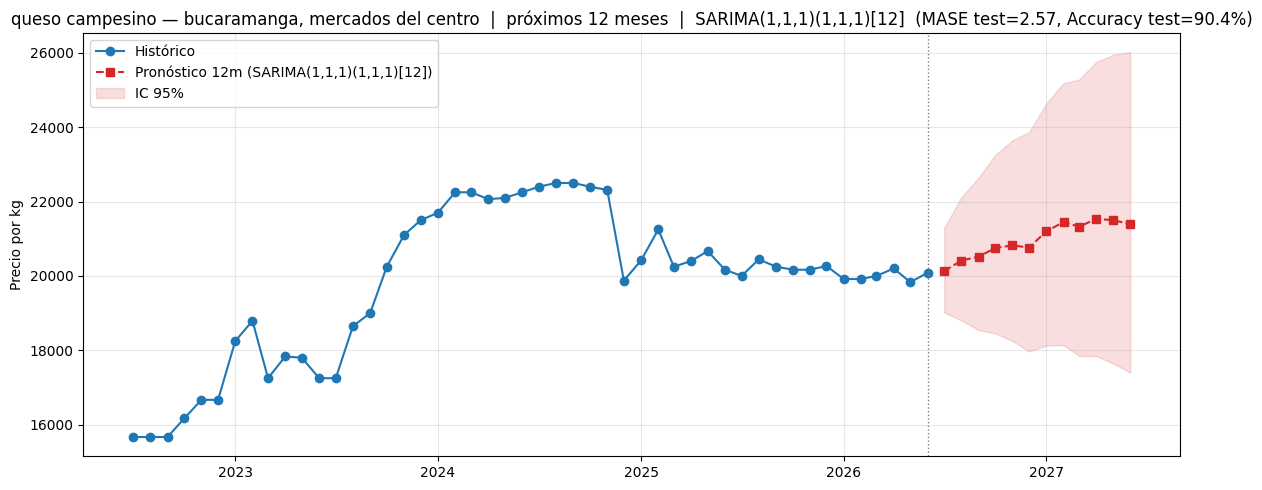

guardado: pronostico_final.csv


In [33]:
plt.figure(figsize=(12, 5))
hist_plot = y.iloc[-min(len(y), 48):]
plt.plot(hist_plot.index, hist_plot.values, 'o-', color='#1f77b4', label='Histórico')
plt.plot(forecast_final.index, forecast_final['pred'], 's--', color='#d62728',
         label=f'Pronóstico {H_FUTURO}m ({GANADOR})')
plt.fill_between(forecast_final.index, forecast_final['lo95'], forecast_final['hi95'],
                 color='#d62728', alpha=.15, label='IC 95%')
plt.axvline(y.index[-1], color='gray', ls=':', lw=1)
plt.title(f'{producto} — {mercado}  |  próximos {H_FUTURO} meses  |  {GANADOR}  '
          f'(MASE test={mase_g:.2f}, Accuracy test={acc_g:.1f}%)')
plt.ylabel('Precio por kg'); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

forecast_final.round(2).to_csv('pronostico_final.csv')
print('guardado: pronostico_final.csv')

**Métricas:**
- MAE: error promedio en las unidades originales.
- RMSE: error que penaliza más los errores grandes.
- MAPE: error promedio expresado en porcentaje.
- sMAPE: error porcentual simétrico entre valores reales y predichos.
- MASE: compara el modelo con un pronóstico de referencia.
- Accuracy: porcentaje de precisión calculado a partir del MAPE.

**Último paso**: Guardar el Modelo para ser utilizado en el **Producto de Datos**

**Producto de Datos**:

- Aplicación Web, formulario que pide los datos y entrega la estimación/predicción/etc.
- Aplicación Móvil
- Tablero o _Dashboard_: Dash, Streamlit, Flask, PowerBI, Tableau, Qlik, Looker
- API: permite hacer las consultas para "embeberlas" en una aplicación de usuario
